Loaded 223,732 rows
Removed 45,582 stale quotes. Remaining: 174,322
Train: 139,457  |  Test: 34,865


/home/krish-tandel/.local/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_36 (Dense)                │ (None, 400)            │         2,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_27 (LeakyReLU)      │ (None, 400)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_27          │ (None, 400)            │         1,600 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 400)            │       160,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_28 (LeakyReLU)      │ (None, 400)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_28          │ (None, 400)            │         1,600 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 400)            │       160,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_29 (LeakyReLU)      │ (None, 400)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_29          │ (None, 400)            │         1,600 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_39 (Dense)                │ (None, 1)              │           401 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 328,801 (1.25 MB)

 Trainable params: 326,401 (1.25 MB)

 Non-trainable params: 2,400 (9.38 KB)

Epoch 1/100
120/120 ━━━━━━━━━━━━━━━━━━━━ 7s 40ms/step - loss: 0.1118 - val_loss: 0.0131 - learning_rate: 0.0010
Epoch 2/100
120/120 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step - loss: 0.0043 - val_loss: 0.0127 - learning_rate: 0.0010
Epoch 3/100
120/120 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - loss: 0.0033 - val_loss: 0.0080 - learning_rate: 0.0010
Epoch 4/100
120/120 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - loss: 0.0027 - val_loss: 0.0046 - learning_rate: 0.0010
Epoch 5/100
120/120 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - loss: 0.0027 - val_loss: 0.0041 - learning_rate: 0.0010
Epoch 6/100
120/120 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - loss: 0.0024 - val_loss: 0.0026 - learning_rate: 0.0010
Epoch 7/100
120/120 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - loss: 0.0024 - val_loss: 0.0025 - learning_rate: 0.0010
Epoch 8/100
120/120 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - loss: 0.0023 - val_loss: 0.0018 - learning_rate: 0.0010
Epoch 9/100
120/120 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - loss: 0.0023 - val_loss: 0.0019 - learning_rate:

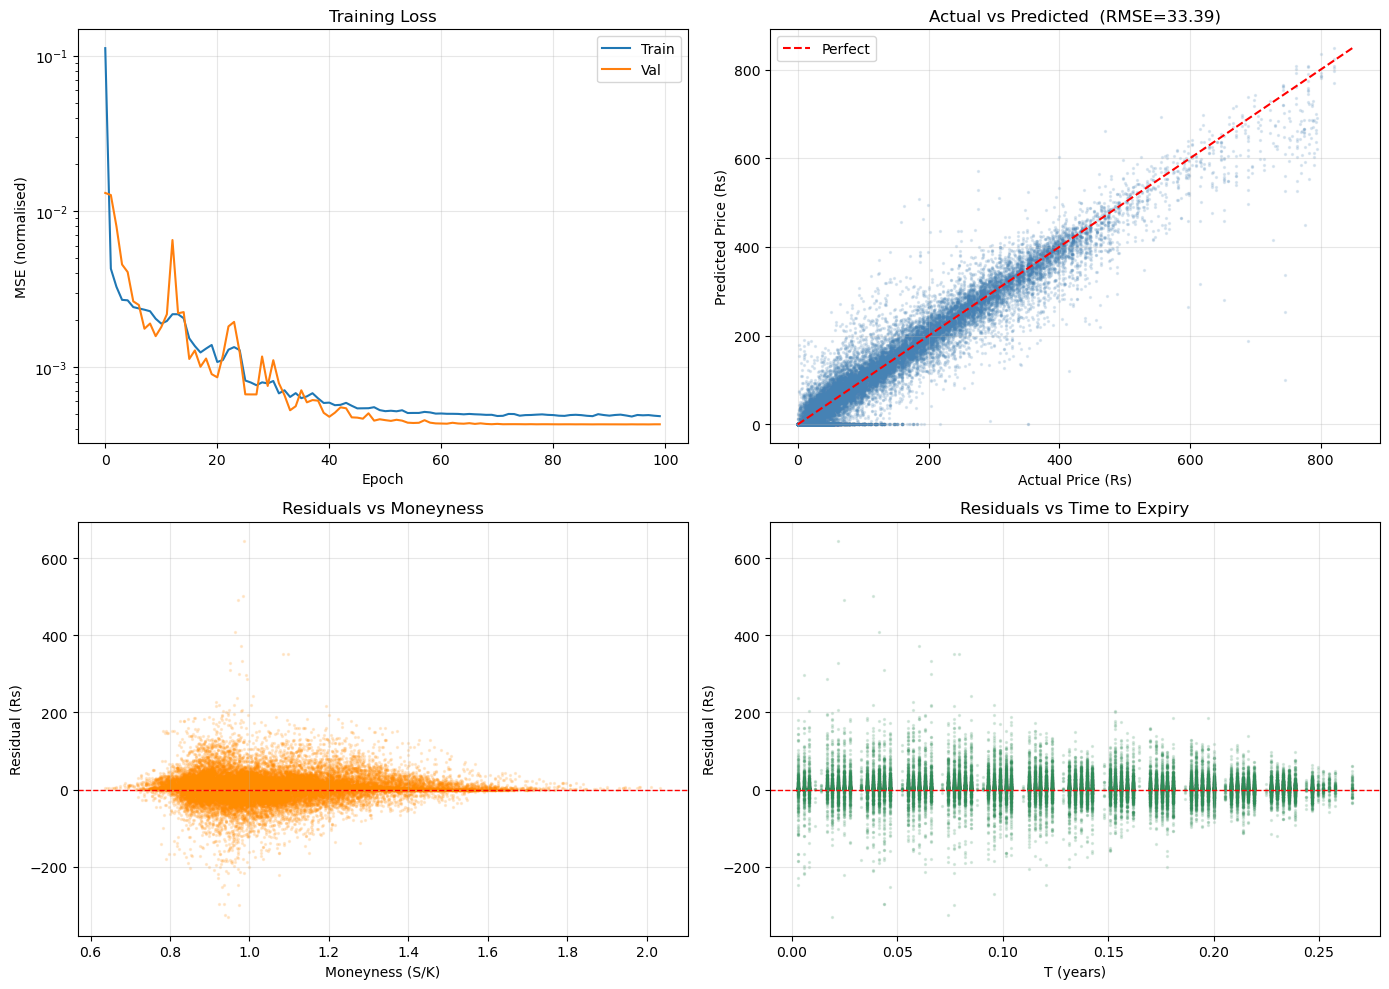

Saved model and scaler.


In [20]:
# MLP1 – Asian Paints Option Pricing (Equilibrium Price)

import os
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization, LeakyReLU
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Load data

try:
    base_dir = os.path.dirname(os.path.abspath(__file__))
except NameError:
    base_dir = os.getcwd()

raw = pd.read_excel(os.path.join(base_dir, "ASIANPAINT_Dataset.xlsx"), sheet_name=None)

all_frames = []
for name, sheet in raw.items():
    sheet = sheet.copy()
    sheet["is_call"] = 1 if name.startswith("CE") else 0
    all_frames.append(sheet)

data = pd.concat(all_frames, ignore_index=True)
data["Date"] = pd.to_datetime(data["Date"])
print(f"Loaded {len(data):,} rows")


# Clean

data = data[data["t"] > 0].copy()

S = data["underlying_value"]
K = data["strike_price"]
intrinsic_val = np.where(data["is_call"] == 1, (S - K).clip(lower=0), (K - S).clip(lower=0))
n_before = len(data)
data = data[data["close"] >= intrinsic_val - 0.05].copy()
print(f"Removed {n_before - len(data):,} stale quotes. Remaining: {len(data):,}")


# Features

data["vol_annual"]  = data["sigma"] * np.sqrt(252)
data["T"]           = data["t"] / 365.0
data["m"]           = data["underlying_value"] / data["strike_price"]
data["vol_sqrt_T"]  = data["vol_annual"] * np.sqrt(data["T"])
data["price_norm"]  = data["close"] / data["strike_price"]

feat_cols = ["m", "T", "r", "vol_annual", "vol_sqrt_T", "is_call"]
X = data[feat_cols].values
y = data["price_norm"].values.reshape(-1, 1)
K_vals = data["strike_price"].values


# Split & scale

idx = np.arange(len(X))
X_tr, X_te, y_tr, y_te, idx_tr, idx_te = train_test_split(
    X, y, idx, test_size=0.2, random_state=42
)

sc = StandardScaler()
X_tr = sc.fit_transform(X_tr)
X_te = sc.transform(X_te)
print(f"Train: {len(X_tr):,}  |  Test: {len(X_te):,}")


# Model

net = Sequential([
    Dense(400, input_shape=(X_tr.shape[1],), kernel_initializer="glorot_uniform"),
    LeakyReLU(0.01),
    BatchNormalization(),
    Dense(400, kernel_initializer="glorot_uniform"),
    LeakyReLU(0.01),
    BatchNormalization(),
    Dense(400, kernel_initializer="glorot_uniform"),
    LeakyReLU(0.01),
    BatchNormalization(),
    Dense(1, activation="relu")
])
net.compile(optimizer=Adam(1e-3), loss="mse")
net.summary()

# Train

cbs = [
    ReduceLROnPlateau(monitor="val_loss", patience=5, factor=0.5, verbose=1),
    EarlyStopping(monitor="val_loss", patience=15, restore_best_weights=True, verbose=1)
]

history = net.fit(X_tr, y_tr, validation_split=0.125, epochs=100,
                  batch_size=1024, callbacks=cbs, verbose=1)

# Evaluate

pred_norm = net.predict(X_te)
strikes_te = K_vals[idx_te].reshape(-1, 1)

pred_actual = pred_norm * strikes_te
y_actual    = y_te * strikes_te

rmse = np.sqrt(mean_squared_error(y_actual, pred_actual))
mae  = mean_absolute_error(y_actual, pred_actual)
r2   = r2_score(y_actual, pred_actual)

print(f"\n{'='*40}")
print(f"  RMSE : {rmse:.4f}")
print(f"  MAE  : {mae:.4f}")
print(f"  R²   : {r2:.6f}")
print(f"{'='*40}")

# call / put breakdown

call_put = data["is_call"].values[idx_te]
for label, flag in [("Call", 1), ("Put", 0)]:
    mask = call_put == flag
    r = np.sqrt(mean_squared_error(y_actual[mask], pred_actual[mask]))
    print(f"  {label} — RMSE: {r:.4f}  R²: {r2_score(y_actual[mask], pred_actual[mask]):.6f}")

# moneyness buckets

m_te = data["m"].values[idx_te]
buckets = [("Deep OTM (<0.90)",   m_te < 0.90),
           ("OTM (0.90-0.97)",   (m_te >= 0.90) & (m_te < 0.97)),
           ("ATM (0.97-1.03)",   (m_te >= 0.97) & (m_te <= 1.03)),
           ("ITM (1.03-1.10)",   (m_te > 1.03)  & (m_te <= 1.10)),
           ("Deep ITM (>1.10)",   m_te > 1.10)]

print("\n  Moneyness breakdown:")
for label, mask in buckets:
    if mask.sum() == 0:
        continue
    r = np.sqrt(mean_squared_error(y_actual[mask], pred_actual[mask]))
    print(f"    {label:22s}  n={mask.sum():>6,}  RMSE={r:.4f}")

# Plots

residuals = (y_actual - pred_actual).ravel()
T_te = data["T"].values[idx_te]

fig, ax = plt.subplots(2, 2, figsize=(14, 10))

ax[0,0].plot(history.history["loss"], label="Train")
ax[0,0].plot(history.history["val_loss"], label="Val")
ax[0,0].set_yscale("log")
ax[0,0].set_title("Training Loss")
ax[0,0].set_xlabel("Epoch")
ax[0,0].set_ylabel("MSE (normalised)")
ax[0,0].legend()
ax[0,0].grid(alpha=0.3)

lim = max(y_actual.max(), pred_actual.max())
ax[0,1].scatter(y_actual.ravel(), pred_actual.ravel(), alpha=0.15, s=2, color="steelblue")
ax[0,1].plot([0, lim], [0, lim], "r--", lw=1.5, label="Perfect")
ax[0,1].set_title(f"Actual vs Predicted  (RMSE={rmse:.2f})")
ax[0,1].set_xlabel("Actual Price (Rs)")
ax[0,1].set_ylabel("Predicted Price (Rs)")
ax[0,1].legend()
ax[0,1].grid(alpha=0.3)

ax[1,0].scatter(m_te, residuals, alpha=0.15, s=2, color="darkorange")
ax[1,0].axhline(0, color="red", ls="--", lw=1)
ax[1,0].set_title("Residuals vs Moneyness")
ax[1,0].set_xlabel("Moneyness (S/K)")
ax[1,0].set_ylabel("Residual (Rs)")
ax[1,0].grid(alpha=0.3)

ax[1,1].scatter(T_te, residuals, alpha=0.15, s=2, color="seagreen")
ax[1,1].axhline(0, color="red", ls="--", lw=1)
ax[1,1].set_title("Residuals vs Time to Expiry")
ax[1,1].set_xlabel("T (years)")
ax[1,1].set_ylabel("Residual (Rs)")
ax[1,1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("mlp1_results.png", dpi=150)
plt.show()

# Save

net.save("mlp1_asianpaints.keras")
joblib.dump(sc, "mlp1_scaler.pkl")
print("Saved model and scaler.")